In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from pandas import ExcelWriter
from pandas import ExcelFile
from sklearn.model_selection import train_test_split
from sklearn import preprocessing

from sklearn.model_selection import cross_val_score,cross_val_predict,cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

In [2]:
#1-list of features, 2-One target, 3- A number for race filtration (0--> No filtration by race) should be imported
feat_list=['DEM_SEX','DEM_AGE','DEM_RACE','CA_Height','CA_Weight','CA_CIRC_W','CA_CIRC_H'] # Any feat_list(numeric) can be imported. 'DEM_SEX' and 'DEM_RACE' are mandatory. 
target="VOL_DXA_TOT" # One target(numeric) should be imported.
filt_race=0 # 0--> No filtration by race, 1-->Filter by race (Filtration by Sex is defult)

address='/Users/Ali/Desktop/Data_Sima/Standard_Labels/AllStyku_v14.xlsx' # Importing dataset. "in_data" will be used in the prediction function
in_data=pd.read_excel(address,encoding = "ISO-8859-1")

In [3]:
def prediction(feat_list, target, filt_race): #3 inputs, 1-list of features, 2-One target, 3- A number for race filtration (0--> No filtration by race)
  
    feat_target_list=feat_list.copy() #feat_target_list includes feat_list elements + target
    feat_target_list.append(target)
    
    feat_reg=feat_list.copy() #"feat_reg" includes features that will be used for regression
    feat_reg.remove('DEM_SEX')
    feat_reg.remove('DEM_RACE')
    
    sam_data=in_data[feat_target_list] #making the sample data set based on the "feat_target_list"
    sam_data=sam_data.dropna() # removing NAN rows from the sample data
    
    #Making datasets for different subgroups of sample dataset (based on sex and race)
    Data_M=sam_data.loc[sam_data['DEM_SEX']=='M']  #Only Male
    Data_F=sam_data.loc[sam_data['DEM_SEX']=='F']  #Only Female
    Data_M_A=Data_M.loc[Data_M['DEM_RACE']=='Asian']   #Male-Asian
    Data_M_W=Data_M.loc[Data_M['DEM_RACE']=='White']   #Male-White
    Data_M_B=Data_M.loc[Data_M['DEM_RACE']=='Black']   #Male-Black
    Data_M_H=Data_M.loc[Data_M['DEM_RACE']=='Hispanic'] #Male-Hispanic
    Data_F_A=Data_F.loc[Data_F['DEM_RACE']=='Asian']   #Female-Asian
    Data_F_W=Data_F.loc[Data_F['DEM_RACE']=='White']   #Female-White
    Data_F_B=Data_F.loc[Data_F['DEM_RACE']=='Black']   #Female-Black
    Data_F_H=Data_F.loc[Data_F['DEM_RACE']=='Hispanic'] #Female-Hispanic
    
    # Checking whether we are filtering by race (8 regression plots) or not (2 regression plots)
    if filt_race==0:
        print(target +' Prediction (Male)')
        LR(Data_M)
        print(target +' Prediction (Female)')
        LR(Data_F)
    elif filt_race!=0:
        print(target +' Prediction (Male-Asian)')
        LR(Data_M_A)
        print(target +' Prediction (Male-White)')
        LR(Data_M_W)
        print(target +' Prediction (Male-Black)')
        LR(Data_M_B)
        print(target +' Prediction (Male-Hispanic)')
        LR(Data_M_H)
        print(target +' Prediction (Female-Asian)')
        LR(Data_F_A)
        print(target +' Prediction (Female-White)')
        LR(Data_F_W)
        print(target +' Prediction (Female-Black)')
        LR(Data_F_B)
        print(target +' Prediction (Female-Hispanic)')
        LR(Data_F_H)
              
    return

In [6]:
#Function fo linear regression and drawing prediction plot. "Data" is the input.

def LR(Data):
    
    feat_reg=feat_list.copy()
    feat_reg.remove('DEM_SEX')
    feat_reg.remove('DEM_RACE')
    
    X=Data[feat_reg]
    y=Data[target]
    X= preprocessing.StandardScaler().fit(X).transform(X)
    clf = LinearRegression()
    scores = cross_validate(clf, X, y, cv=3,return_train_score=True)
    y_hat=cross_val_predict(clf, X, y, cv=3)
    #print("Train Accuracy: %0.2f +/- %0.2f" % (scores['train_score'].mean(), scores['train_score'].std() * 2))
    print("Test Accuracy: %0.2f +/- %0.2f" % (scores['test_score'].mean(), scores['test_score'].std() * 2))
    fig, ax = plt.subplots()
    ax.scatter(y, y_hat, edgecolors=(0, 0, 1))
    ax.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
    ax.set_xlabel('Measured')
    ax.set_ylabel('Predicted')
    plt.show()
    
    return

VOL_DXA_TOT Prediction (Male)
Test Accuracy: 0.96 +/- 0.02


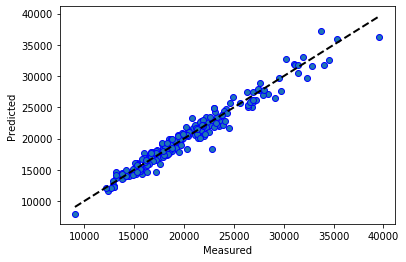

VOL_DXA_TOT Prediction (Female)
Test Accuracy: 0.94 +/- 0.04


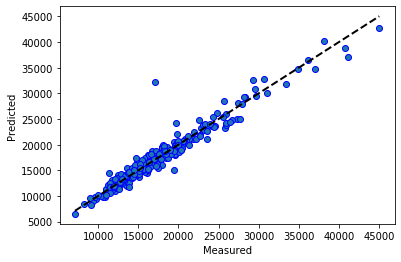

In [5]:
# A sample of running this function
prediction(feat_list, target, filt_race)